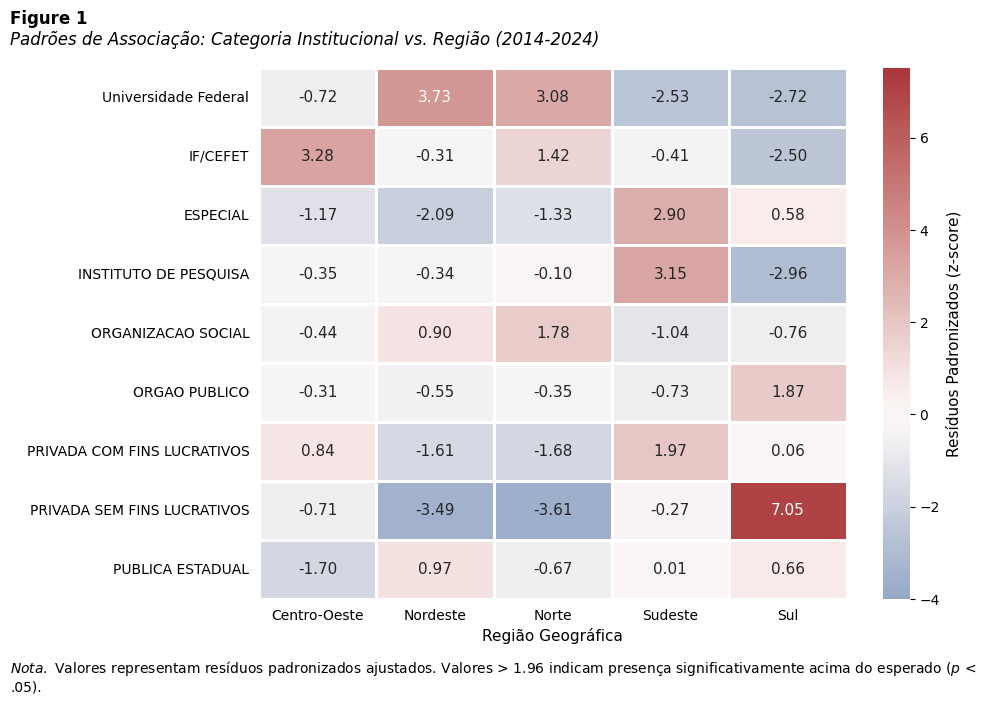

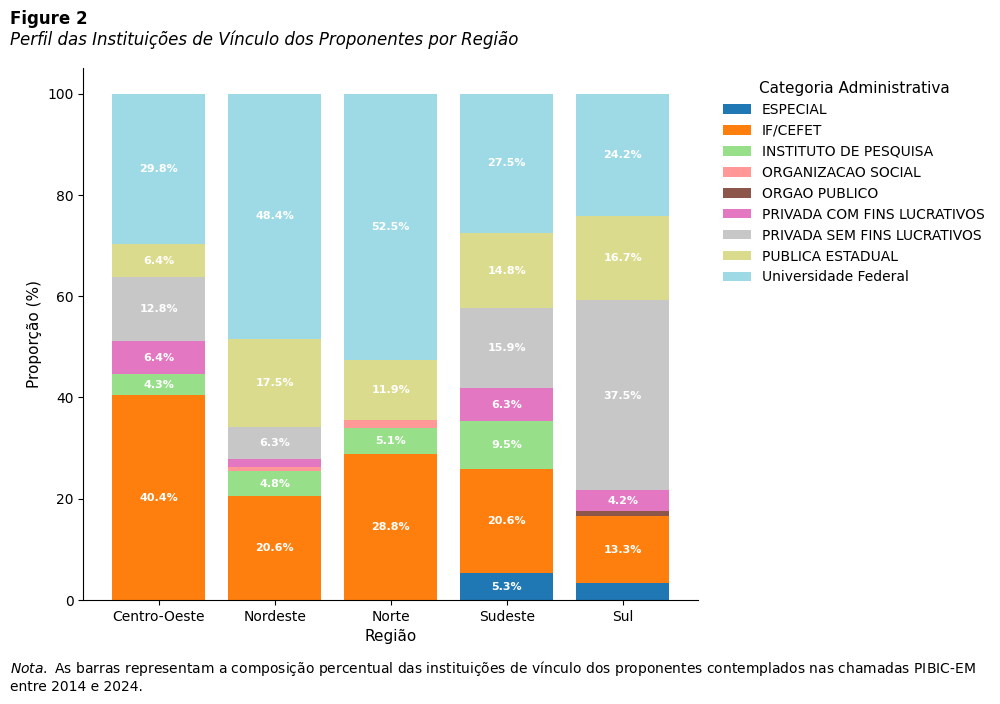

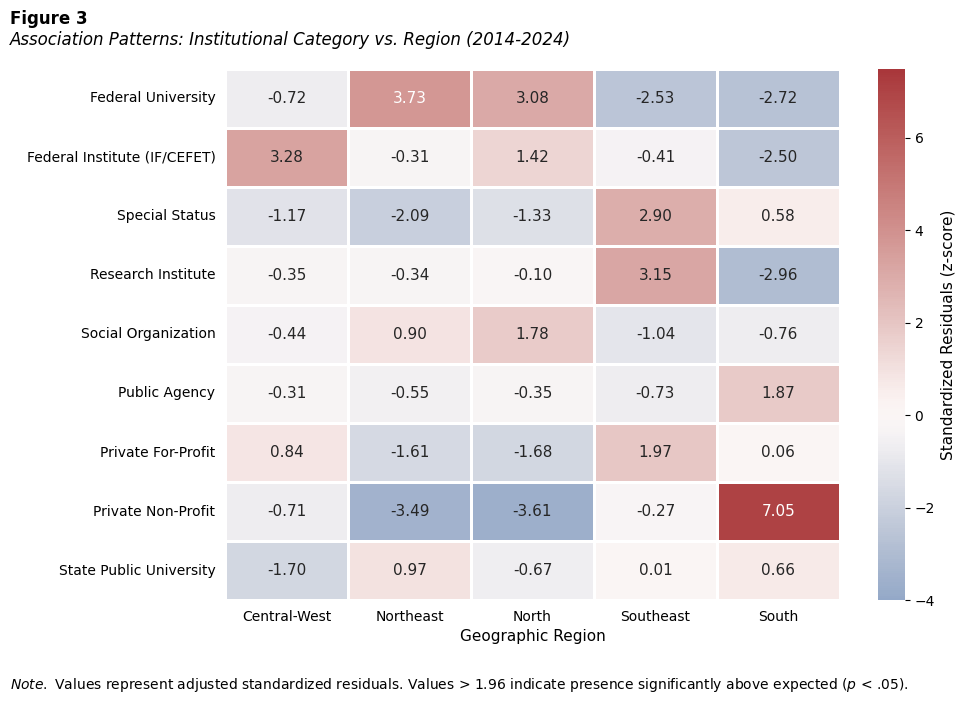

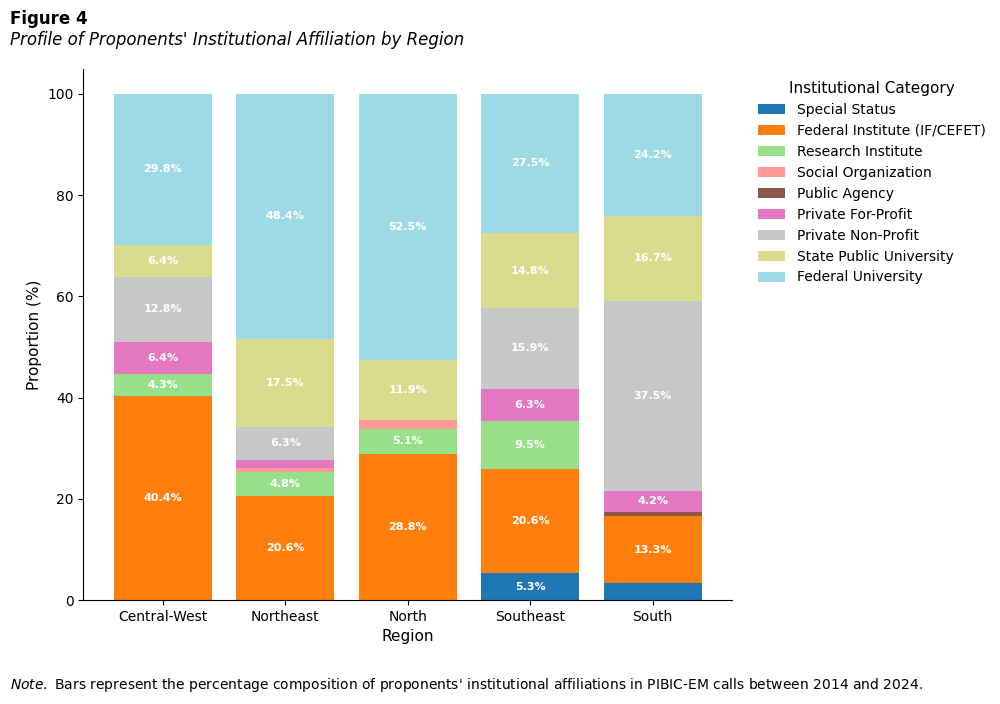

Gráficos APA 7 gerados e exibidos.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# ==============================================================================
# 1. CONFIGURAÇÃO GERAL DO ESTILO APA 7
# ==============================================================================
# Resetar parâmetros para garantir limpeza
plt.rcParams.update(plt.rcParamsDefault)

# Fontes e Tamanhos (Arial ou Sans-Serif genérica que simule Arial)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 11
rcParams['axes.titlesize'] = 12
rcParams['axes.labelsize'] = 11
rcParams['xtick.labelsize'] = 10
rcParams['ytick.labelsize'] = 10
rcParams['legend.fontsize'] = 10

# Remover "chartjunk" (bordas desnecessárias)
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.edgecolor'] = 'black'
rcParams['axes.linewidth'] = 0.8

# ==============================================================================
# 2. DADOS
# ==============================================================================
dados_residuos = {
    'Categoria': [
        'Universidade Federal', 'IF/CEFET', 'ESPECIAL', 'INSTITUTO DE PESQUISA',
        'ORGANIZACAO SOCIAL', 'ORGAO PUBLICO', 'PRIVADA COM FINS LUCRATIVOS',
        'PRIVADA SEM FINS LUCRATIVOS', 'PUBLICA ESTADUAL'
    ],
    'Centro-Oeste': [-0.72,  3.28, -1.17, -0.35, -0.44, -0.31,  0.84, -0.71, -1.70],
    'Nordeste':     [ 3.73, -0.31, -2.09, -0.34,  0.90, -0.55, -1.61, -3.49,  0.97],
    'Norte':        [ 3.08,  1.42, -1.33, -0.10,  1.78, -0.35, -1.68, -3.61, -0.67],
    'Sudeste':      [-2.53, -0.41,  2.90,  3.15, -1.04, -0.73,  1.97, -0.27,  0.01],
    'Sul':          [-2.72, -2.50,  0.58, -2.96, -0.76,  1.87,  0.06,  7.05,  0.66]
}

# Carregar dados brutos para barras
nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
df_raw = pd.read_csv(nome_arquivo)

# Dicionários de Tradução
mapa_categorias_en = {
    'Universidade Federal': 'Federal University',
    'IF/CEFET': 'Federal Institute (IF/CEFET)',
    'ESPECIAL': 'Special Status',
    'INSTITUTO DE PESQUISA': 'Research Institute',
    'ORGANIZACAO SOCIAL': 'Social Organization',
    'ORGAO PUBLICO': 'Public Agency',
    'PRIVADA COM FINS LUCRATIVOS': 'Private For-Profit',
    'PRIVADA SEM FINS LUCRATIVOS': 'Private Non-Profit',
    'PUBLICA ESTADUAL': 'State Public University'
}
mapa_regioes_en = {'Centro-Oeste': 'Central-West', 'Nordeste': 'Northeast',
                   'Norte': 'North', 'Sudeste': 'Southeast', 'Sul': 'South'}

# ==============================================================================
# 3. FUNÇÃO AUXILIAR PARA CABEÇALHO APA (Título e Número)
# ==============================================================================
def add_apa_header_footer(fig, num_fig, titulo, nota):
    # Texto: Figura X (Negrito)
    fig.text(0.0, 0.96, f"Figura {num_fig}" if "Figura" in str(num_fig) else f"Figure {num_fig}",
             fontsize=12, weight='bold', ha='left')
    # Texto: Título (Itálico)
    fig.text(0.0, 0.93, titulo, fontsize=12, style='italic', ha='left')
    # Texto: Nota (Rodapé)
    fig.text(0.0, 0.01, nota, fontsize=10, ha='left', wrap=True)

# ==============================================================================
# 4. GERAR GRÁFICOS (PT e EN)
# ==============================================================================

# --- A. HEATMAP (PT) ---
df_heat_pt = pd.DataFrame(dados_residuos).set_index('Categoria')
fig, ax = plt.subplots(figsize=(10, 7)) # Altura ajustada para caber título/nota

# Heatmap com linhas brancas para separação clara (Clean look)
sns.heatmap(df_heat_pt, annot=True, fmt=".2f", cmap="vlag", center=0,
            vmin=-4, vmax=7.5, linewidths=1, linecolor='white',
            cbar_kws={'label': 'Resíduos Padronizados (z-score)'}, ax=ax)

# Ajustes de Eixos
ax.set_ylabel('')
ax.set_xlabel('Região Geográfica')
ax.tick_params(left=False, bottom=False) # Heatmap geralmente não tem ticks externos

# Adicionar Elementos APA
add_apa_header_footer(
    fig, "1",
    "Padrões de Associação: Categoria Institucional vs. Região (2014-2024)",
    r"$\it{Nota.}$ Valores representam resíduos padronizados ajustados. Valores > 1.96 indicam presença significativamente acima do esperado ($p$ < .05)."
)

plt.tight_layout(rect=[0, 0.05, 1, 0.92]) # Deixa espaço para título e nota
plt.savefig('apa_fig1_heatmap_pt.png', dpi=300, bbox_inches='tight') # bbox_inches garante que nada corte
plt.show()

# --- B. BARRAS EMPILHADAS (PT) ---
tabela_pt = pd.crosstab(df_raw['regiao_corrigida'], df_raw['categoria_adm_corrigida'], normalize='index') * 100
fig, ax = plt.subplots(figsize=(10, 7))

tabela_pt.plot(kind='bar', stacked=True, width=0.8, colormap='tab20', ax=ax)

# Limpeza APA
ax.set_ylabel('Proporção (%)')
ax.set_xlabel('Região')
plt.xticks(rotation=0)
# Legenda limpa, sem caixa, posicionada fora ou abaixo
ax.legend(title='Categoria Administrativa', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

# Adicionar rótulos de dados (apenas > 4%)
for c in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 4 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=8, color='white', weight='bold')

add_apa_header_footer(
    fig, "2",
    "Perfil das Instituições de Vínculo dos Proponentes por Região",
    r"$\it{Nota.}$ As barras representam a composição percentual das instituições de vínculo dos proponentes contemplados nas chamadas PIBIC-EM entre 2014 e 2024."
)

plt.tight_layout(rect=[0, 0.05, 1, 0.92])
plt.savefig('apa_fig2_barras_pt.png', dpi=300, bbox_inches='tight')
plt.show()

# --- C. HEATMAP (EN) ---
df_heat_en = df_heat_pt.rename(index=mapa_categorias_en, columns=mapa_regioes_en)
fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(df_heat_en, annot=True, fmt=".2f", cmap="vlag", center=0,
            vmin=-4, vmax=7.5, linewidths=1, linecolor='white',
            cbar_kws={'label': 'Standardized Residuals (z-score)'}, ax=ax)

ax.set_ylabel('')
ax.set_xlabel('Geographic Region')
ax.tick_params(left=False, bottom=False)

add_apa_header_footer(
    fig, "3",
    "Association Patterns: Institutional Category vs. Region (2014-2024)",
    r"$\it{Note.}$ Values represent adjusted standardized residuals. Values > 1.96 indicate presence significantly above expected ($p$ < .05)."
)

plt.tight_layout(rect=[0, 0.05, 1, 0.92])
plt.savefig('apa_fig3_heatmap_en.png', dpi=300, bbox_inches='tight')
plt.show()

# --- D. BARRAS EMPILHADAS (EN) ---
tabela_en = tabela_pt.rename(index=mapa_regioes_en, columns=mapa_categorias_en)
fig, ax = plt.subplots(figsize=(10, 7))

tabela_en.plot(kind='bar', stacked=True, width=0.8, colormap='tab20', ax=ax)

ax.set_ylabel('Proportion (%)')
ax.set_xlabel('Region')
plt.xticks(rotation=0)
ax.legend(title='Institutional Category', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

for c in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 4 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=8, color='white', weight='bold')

add_apa_header_footer(
    fig, "4",
    "Profile of Proponents' Institutional Affiliation by Region",
    r"$\it{Note.}$ Bars represent the percentage composition of proponents' institutional affiliations in PIBIC-EM calls between 2014 and 2024."
)

plt.tight_layout(rect=[0, 0.05, 1, 0.92])
plt.savefig('apa_fig4_barras_en.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráficos APA 7 gerados e exibidos.")

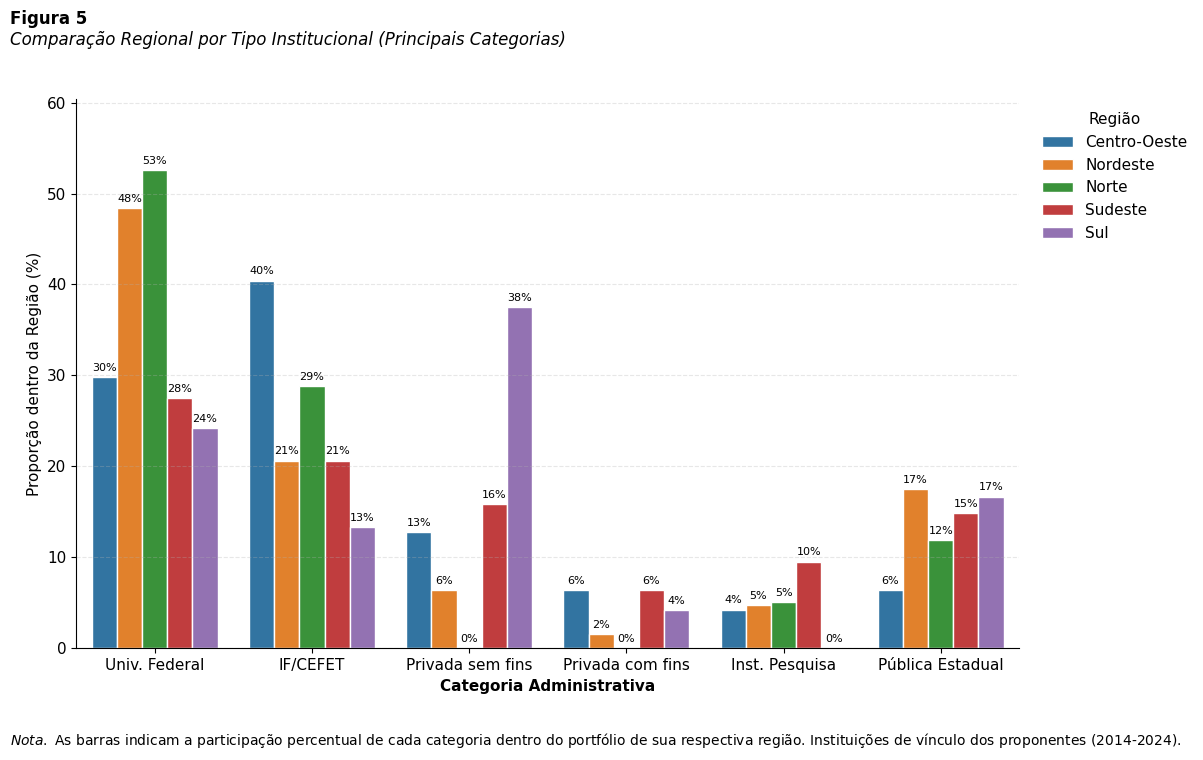

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# 1. Configuração Estética (APA 7)
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 11
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.edgecolor'] = 'black'
rcParams['axes.linewidth'] = 0.8
rcParams['legend.frameon'] = False

# 2. Dados
nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
df = pd.read_csv(nome_arquivo)

# Calcular percentuais dentro de cada região
tabela_pct = pd.crosstab(df['regiao_corrigida'], df['categoria_adm_corrigida'], normalize='index') * 100

# Filtrar e Renomear
cats_interesse = [
    'Universidade Federal', 'IF/CEFET', 'PRIVADA SEM FINS LUCRATIVOS',
    'PRIVADA COM FINS LUCRATIVOS', 'INSTITUTO DE PESQUISA', 'PUBLICA ESTADUAL'
]
mapa_nomes_pt = {
    'PRIVADA SEM FINS LUCRATIVOS': 'Privada sem fins',
    'PRIVADA COM FINS LUCRATIVOS': 'Privada com fins',
    'INSTITUTO DE PESQUISA': 'Inst. Pesquisa',
    'PUBLICA ESTADUAL': 'Pública Estadual',
    'Universidade Federal': 'Univ. Federal'
}

df_plot = tabela_pct[cats_interesse].rename(columns=mapa_nomes_pt)
df_long_pt = df_plot.reset_index().melt(id_vars='regiao_corrigida', var_name='Categoria', value_name='Percentual')

# 3. Plotagem
fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(
    data=df_long_pt,
    x='Categoria',
    y='Percentual',
    hue='regiao_corrigida',
    palette='tab10',
    edgecolor='white',
    linewidth=1,
    ax=ax
)

# Ajustes APA
ax.set_xlabel('Categoria Administrativa', fontsize=11, weight='bold')
ax.set_ylabel('Proporção dentro da Região (%)', fontsize=11)
ax.set_ylim(0, df_long_pt['Percentual'].max() * 1.15)
plt.legend(title='Região', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Rótulos nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', padding=3, fontsize=8)

# Cabeçalho e Nota (APA)
fig.text(0.0, 0.98, "Figura 5", fontsize=12, weight='bold', ha='left')
fig.text(0.0, 0.95, "Comparação Regional por Tipo Institucional (Principais Categorias)",
         fontsize=12, style='italic', ha='left')
nota_texto = (
    r"$\it{Nota.}$ As barras indicam a participação percentual de cada categoria dentro do portfólio "
    "de sua respectiva região. Instituições de vínculo dos proponentes (2014-2024)."
)
fig.text(0.0, -0.05, nota_texto, fontsize=10, ha='left', wrap=True)

plt.tight_layout(rect=[0, 0.0, 1, 0.9])
plt.savefig('apa_fig5_barras_comparativas_PT.png', dpi=300, bbox_inches='tight')
plt.show()

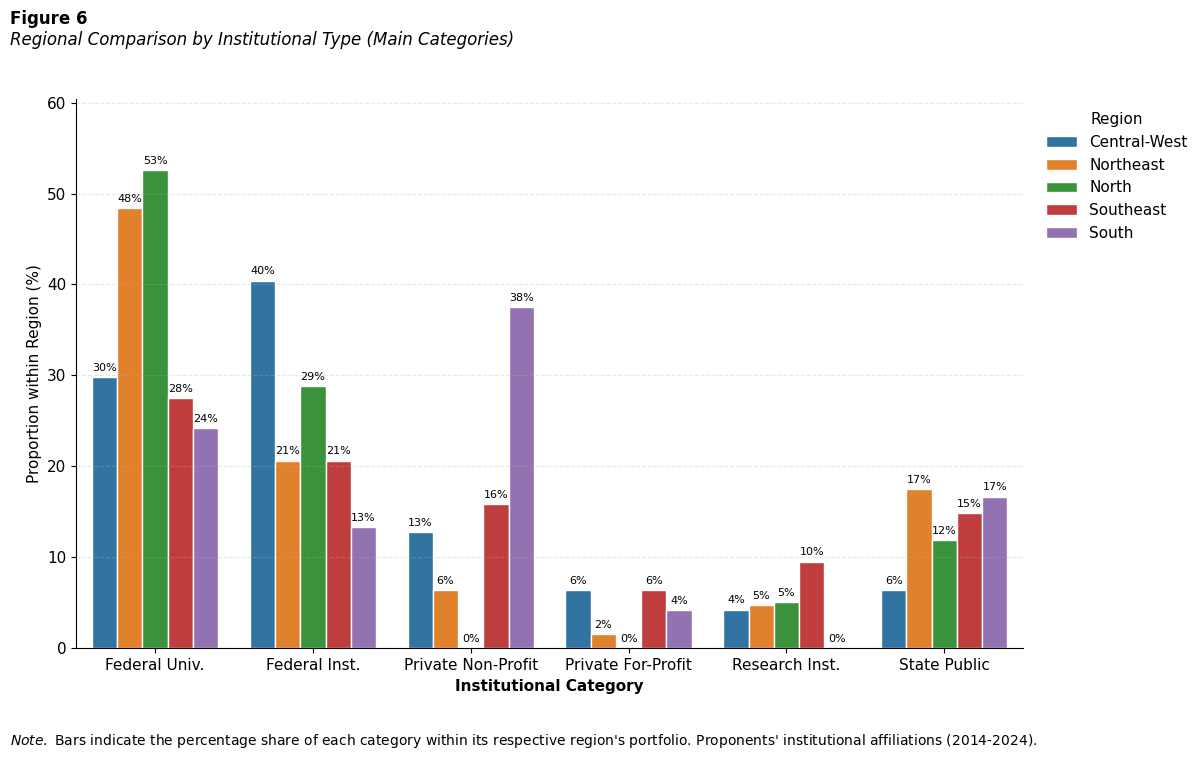

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# 1. Configuração Estética (APA 7)
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 11
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.edgecolor'] = 'black'
rcParams['axes.linewidth'] = 0.8
rcParams['legend.frameon'] = False

# 2. Dados e Traduções
nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
df = pd.read_csv(nome_arquivo)

tabela_pct = pd.crosstab(df['regiao_corrigida'], df['categoria_adm_corrigida'], normalize='index') * 100

cats_interesse = [
    'Universidade Federal', 'IF/CEFET', 'PRIVADA SEM FINS LUCRATIVOS',
    'PRIVADA COM FINS LUCRATIVOS', 'INSTITUTO DE PESQUISA', 'PUBLICA ESTADUAL'
]

# Mapas de Tradução
mapa_regioes_en = {
    'Centro-Oeste': 'Central-West', 'Nordeste': 'Northeast',
    'Norte': 'North', 'Sudeste': 'Southeast', 'Sul': 'South'
}
mapa_cats_en = {
    'Universidade Federal': 'Federal Univ.',
    'IF/CEFET': 'Federal Inst.',
    'PRIVADA SEM FINS LUCRATIVOS': 'Private Non-Profit',
    'PRIVADA COM FINS LUCRATIVOS': 'Private For-Profit',
    'INSTITUTO DE PESQUISA': 'Research Inst.',
    'PUBLICA ESTADUAL': 'State Public'
}

# Preparar DataFrame em Inglês
df_plot = tabela_pct[cats_interesse].copy()
df_plot = df_plot.rename(index=mapa_regioes_en, columns=mapa_cats_en)
df_long_en = df_plot.reset_index().melt(id_vars='regiao_corrigida', var_name='Category', value_name='Percentual')

# 3. Plotagem
fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(
    data=df_long_en,
    x='Category',
    y='Percentual',
    hue='regiao_corrigida',
    palette='tab10',
    edgecolor='white',
    linewidth=1,
    ax=ax
)

# Ajustes APA
ax.set_xlabel('Institutional Category', fontsize=11, weight='bold')
ax.set_ylabel('Proportion within Region (%)', fontsize=11)
ax.set_ylim(0, df_long_en['Percentual'].max() * 1.15)
plt.legend(title='Region', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Rótulos
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', padding=3, fontsize=8)

# Cabeçalho e Nota (APA)
fig.text(0.0, 0.98, "Figure 6", fontsize=12, weight='bold', ha='left')
fig.text(0.0, 0.95, "Regional Comparison by Institutional Type (Main Categories)",
         fontsize=12, style='italic', ha='left')
note_text = (
    r"$\it{Note.}$ Bars indicate the percentage share of each category within its respective region's portfolio. "
    "Proponents' institutional affiliations (2014-2024)."
)
fig.text(0.0, -0.05, note_text, fontsize=10, ha='left', wrap=True)

plt.tight_layout(rect=[0, 0.0, 1, 0.9])
plt.savefig('apa_fig6_dodged_bars_comparative_EN.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipython-input-3236750626.py:45: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  brasil_points['centroide'] = brasil_points.geometry.centroid


--- Gerando Mapa em Português ---


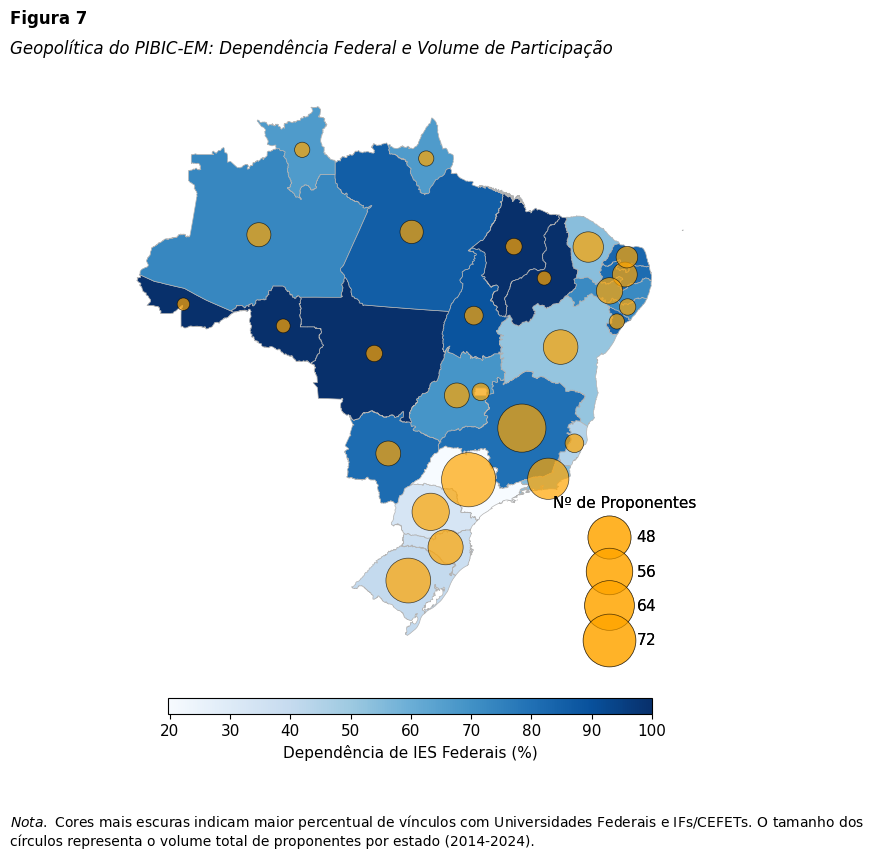


--- Gerando Mapa em Inglês ---


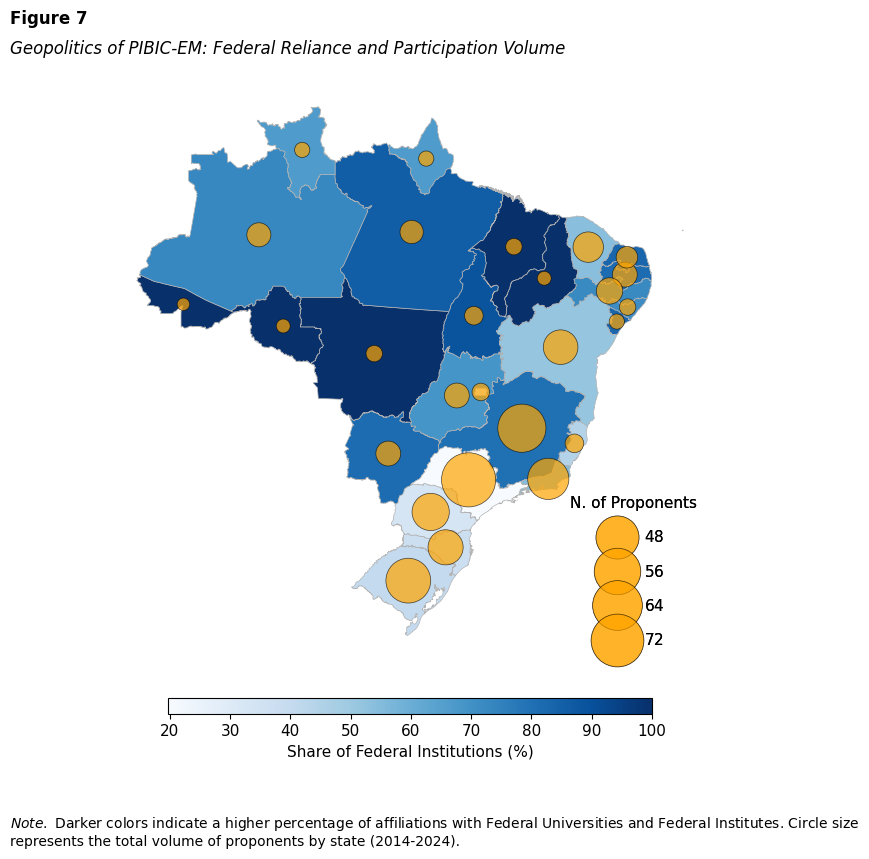

In [5]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ==============================================================================
# 1. CONFIGURAÇÃO ESTÉTICA (APA 7)
# ==============================================================================
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 11
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.left'] = False
rcParams['axes.spines.bottom'] = False # Mapas não precisam de bordas de eixo
rcParams['legend.frameon'] = False

# ==============================================================================
# 2. PREPARAÇÃO DOS DADOS (CÁLCULOS)
# ==============================================================================
nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
df = pd.read_csv(nome_arquivo)

# 1. Agrupar por UF (Volume Total)
agg_df = df.groupby('uf').agg(volume_total=('id_pesq', 'count')).reset_index()

# 2. Filtrar e contar Federais (UF + IF/CEFET)
filtro_federal = df['categoria_adm_corrigida'].isin(['Universidade Federal', 'IF/CEFET'])
federal_df = df[filtro_federal].groupby('uf').agg(volume_federal=('id_pesq', 'count')).reset_index()

# 3. Unir e calcular Porcentagem
agg_df = agg_df.merge(federal_df, on='uf', how='left')
agg_df['volume_federal'] = agg_df['volume_federal'].fillna(0)
agg_df['percentual_federais'] = (agg_df['volume_federal'] / agg_df['volume_total']) * 100

# 4. Baixar e Unir com Malha Geográfica
url_mapa = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
brasil = gpd.read_file(url_mapa)
brasil = brasil.merge(agg_df, left_on='sigla', right_on='uf', how='left')
brasil['percentual_federais'] = brasil['percentual_federais'].fillna(0)

# Calcular centroides para as bolhas
brasil_points = brasil.copy()
brasil_points['centroide'] = brasil_points.geometry.centroid

# ==============================================================================
# 3. FUNÇÃO DE PLOTAGEM (FLEXÍVEL PARA PT/EN)
# ==============================================================================
def plot_apa_map(lang='pt'):
    fig, ax = plt.subplots(figsize=(10, 10))

    # Textos por idioma
    if lang == 'pt':
        title_legend_color = "Dependência de IES Federais (%)"
        title_legend_size = "Nº de Proponentes"
        num_fig = "Figura 7"
        title_text = "Geopolítica do PIBIC-EM: Dependência Federal e Volume de Participação"
        note_text = (
            r"$\it{Nota.}$ Cores mais escuras indicam maior percentual de vínculos com Universidades Federais "
            "e IFs/CEFETs. O tamanho dos círculos representa o volume total de proponentes por estado (2014-2024)."
        )
        file_name = "apa_fig7_mapa_geopolitico_PT.png"
    else:
        title_legend_color = "Share of Federal Institutions (%)"
        title_legend_size = "N. of Proponents"
        num_fig = "Figure 7"
        title_text = "Geopolitics of PIBIC-EM: Federal Reliance and Participation Volume"
        note_text = (
            r"$\it{Note.}$ Darker colors indicate a higher percentage of affiliations with Federal Universities "
            "and Federal Institutes. Circle size represents the total volume of proponents by state (2014-2024)."
        )
        file_name = "apa_fig7_geopolitical_map_EN.png"

    # 1. Camada Base (Choropleth)
    brasil.plot(
        column='percentual_federais',
        cmap='Blues',
        linewidth=0.5,
        edgecolor='0.7',
        ax=ax,
        legend=True,
        legend_kwds={
            'label': title_legend_color,
            'orientation': "horizontal",
            'shrink': 0.5,
            'pad': 0.05,
            'aspect': 30
        }
    )

    # 2. Camada de Bolhas
    # Escala ajustada para visibilidade
    scale_factor = 20
    scatter = ax.scatter(
        brasil_points['centroide'].x,
        brasil_points['centroide'].y,
        s=brasil_points['volume_total'] * scale_factor,
        c='orange',
        alpha=0.7,
        edgecolor='black',
        linewidth=0.5,
        label=title_legend_size
    )

    # Legenda manual para o tamanho das bolhas
    handles, labels = scatter.legend_elements(
        prop="sizes", alpha=0.6,
        func=lambda x: x/scale_factor,
        color='orange', markeredgecolor='black'
    )
    # Selecionar 3 exemplos representativos para a legenda
    legend2 = ax.legend(handles[-4:], labels[-4:], loc="lower right",
                        title=title_legend_size, frameon=False, labelspacing=1.2)
    ax.add_artist(legend2)

    # Limpeza final
    ax.set_axis_off()

    # Cabeçalho e Rodapé APA
    # Ajuste vertical manual (y) pode ser necessário dependendo da geometria
    fig.text(0.1, 0.92, num_fig, fontsize=12, weight='bold', ha='left')
    fig.text(0.1, 0.89, title_text, fontsize=12, style='italic', ha='left')
    fig.text(0.1, 0.10, note_text, fontsize=10, ha='left', wrap=True, color='black')

    plt.tight_layout(rect=[0, 0.12, 1, 0.88]) # Margens para texto
    plt.savefig(file_name, dpi=300, bbox_inches='tight')
    plt.show()

# ==============================================================================
# 4. EXECUTAR
# ==============================================================================
print("--- Gerando Mapa em Português ---")
plot_apa_map('pt')

print("\n--- Gerando Mapa em Inglês ---")
plot_apa_map('en')

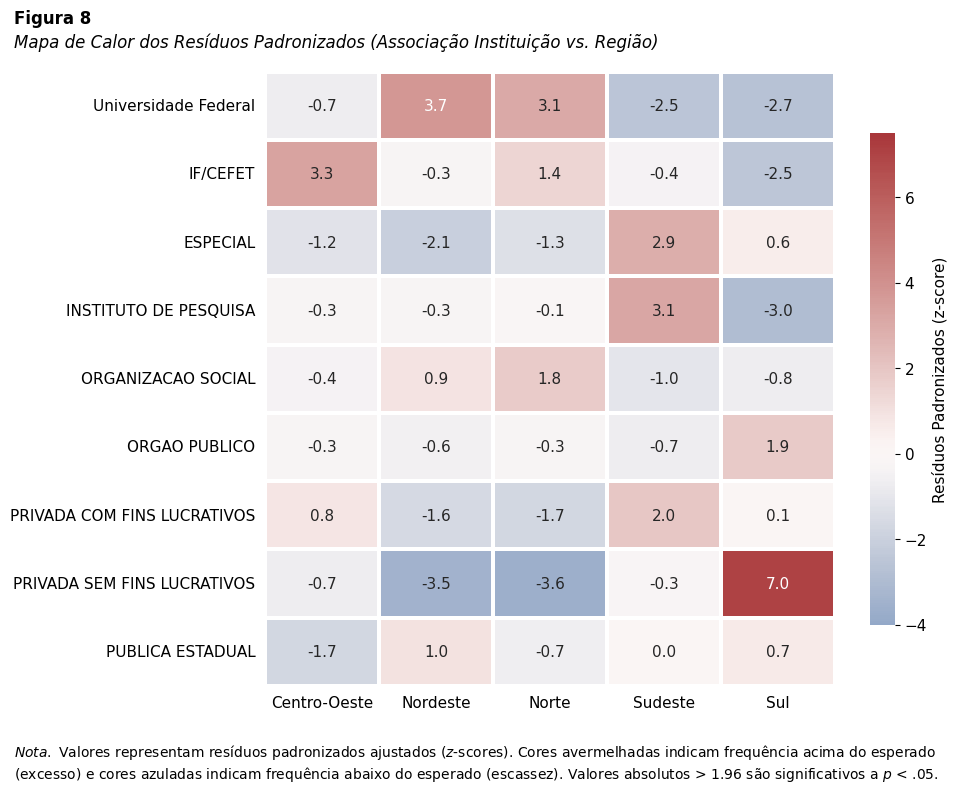

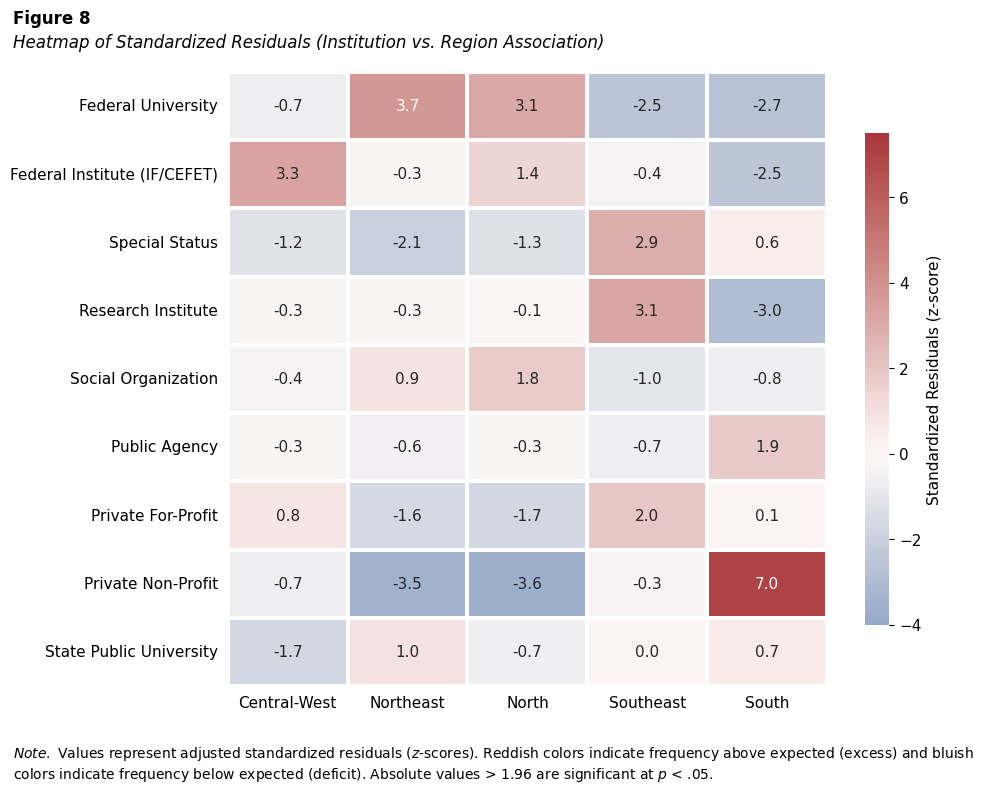

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# ==============================================================================
# 1. CONFIGURAÇÃO ESTÉTICA (APA 7)
# ==============================================================================
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 11
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.left'] = False
rcParams['axes.spines.bottom'] = False
rcParams['legend.frameon'] = False

# ==============================================================================
# 2. DADOS DOS RESÍDUOS (JAMOVI)
# ==============================================================================
# Inserindo manualmente para garantir precisão exata com seu teste (ex: 7.05)
dados_residuos = {
    'Categoria': [
        'Universidade Federal', 'IF/CEFET', 'ESPECIAL', 'INSTITUTO DE PESQUISA',
        'ORGANIZACAO SOCIAL', 'ORGAO PUBLICO', 'PRIVADA COM FINS LUCRATIVOS',
        'PRIVADA SEM FINS LUCRATIVOS', 'PUBLICA ESTADUAL'
    ],
    'Centro-Oeste': [-0.72,  3.28, -1.17, -0.35, -0.44, -0.31,  0.84, -0.71, -1.70],
    'Nordeste':     [ 3.73, -0.31, -2.09, -0.34,  0.90, -0.55, -1.61, -3.49,  0.97],
    'Norte':        [ 3.08,  1.42, -1.33, -0.10,  1.78, -0.35, -1.68, -3.61, -0.67],
    'Sudeste':      [-2.53, -0.41,  2.90,  3.15, -1.04, -0.73,  1.97, -0.27,  0.01],
    'Sul':          [-2.72, -2.50,  0.58, -2.96, -0.76,  1.87,  0.06,  7.05,  0.66]
}

# Traduções
mapa_categorias_en = {
    'Universidade Federal': 'Federal University',
    'IF/CEFET': 'Federal Institute (IF/CEFET)',
    'ESPECIAL': 'Special Status',
    'INSTITUTO DE PESQUISA': 'Research Institute',
    'ORGANIZACAO SOCIAL': 'Social Organization',
    'ORGAO PUBLICO': 'Public Agency',
    'PRIVADA COM FINS LUCRATIVOS': 'Private For-Profit',
    'PRIVADA SEM FINS LUCRATIVOS': 'Private Non-Profit',
    'PUBLICA ESTADUAL': 'State Public University'
}
mapa_regioes_en = {'Centro-Oeste': 'Central-West', 'Nordeste': 'Northeast',
                   'Norte': 'North', 'Sudeste': 'Southeast', 'Sul': 'South'}

# ==============================================================================
# 3. GERAÇÃO DOS GRÁFICOS
# ==============================================================================

# --- VERSÃO PORTUGUÊS (PT) ---
df_pt = pd.DataFrame(dados_residuos).set_index('Categoria')

fig, ax = plt.subplots(figsize=(10, 8))

# Heatmap
sns.heatmap(
    df_pt,
    annot=True,
    fmt=".1f", # Uma casa decimal é suficiente para resíduos e limpa o visual
    cmap="vlag",
    center=0,
    vmin=-4, vmax=7.5,
    linewidths=1.5,
    linecolor='white',
    cbar_kws={'label': 'Resíduos Padronizados (z-score)', 'shrink': 0.8},
    ax=ax
)

# Estética
ax.set_ylabel('')
ax.set_xlabel('')
ax.tick_params(left=False, bottom=False) # Remove ticks externos

# Títulos e Notas APA
fig.text(0.02, 0.96, "Figura 8", fontsize=12, weight='bold')
fig.text(0.02, 0.93, "Mapa de Calor dos Resíduos Padronizados (Associação Instituição vs. Região)", fontsize=12, style='italic')
note_pt = (
    r"$\it{Nota.}$ Valores representam resíduos padronizados ajustados ($z$-scores). "
    "Cores avermelhadas indicam frequência acima do esperado (excesso) e cores azuladas indicam frequência abaixo do esperado (escassez). "
    "Valores absolutos > 1.96 são significativos a $p$ < .05."
)
fig.text(0.02, 0.02, note_pt, fontsize=10, ha='left', wrap=True)

plt.tight_layout(rect=[0, 0.08, 1, 0.92])
plt.savefig('apa_fig8_heatmap_residuos_PT.png', dpi=300, bbox_inches='tight')
plt.show()


# --- VERSÃO INGLÊS (EN) ---
df_en = df_pt.rename(index=mapa_categorias_en, columns=mapa_regioes_en)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    df_en,
    annot=True,
    fmt=".1f",
    cmap="vlag",
    center=0,
    vmin=-4, vmax=7.5,
    linewidths=1.5,
    linecolor='white',
    cbar_kws={'label': 'Standardized Residuals (z-score)', 'shrink': 0.8},
    ax=ax
)

ax.set_ylabel('')
ax.set_xlabel('')
ax.tick_params(left=False, bottom=False)

fig.text(0.02, 0.96, "Figure 8", fontsize=12, weight='bold')
fig.text(0.02, 0.93, "Heatmap of Standardized Residuals (Institution vs. Region Association)", fontsize=12, style='italic')
note_en = (
    r"$\it{Note.}$ Values represent adjusted standardized residuals ($z$-scores). "
    "Reddish colors indicate frequency above expected (excess) and bluish colors indicate frequency below expected (deficit). "
    "Absolute values > 1.96 are significant at $p$ < .05."
)
fig.text(0.02, 0.02, note_en, fontsize=10, ha='left', wrap=True)

plt.tight_layout(rect=[0, 0.08, 1, 0.92])
plt.savefig('apa_fig8_heatmap_residuals_EN.png', dpi=300, bbox_inches='tight')
plt.show()

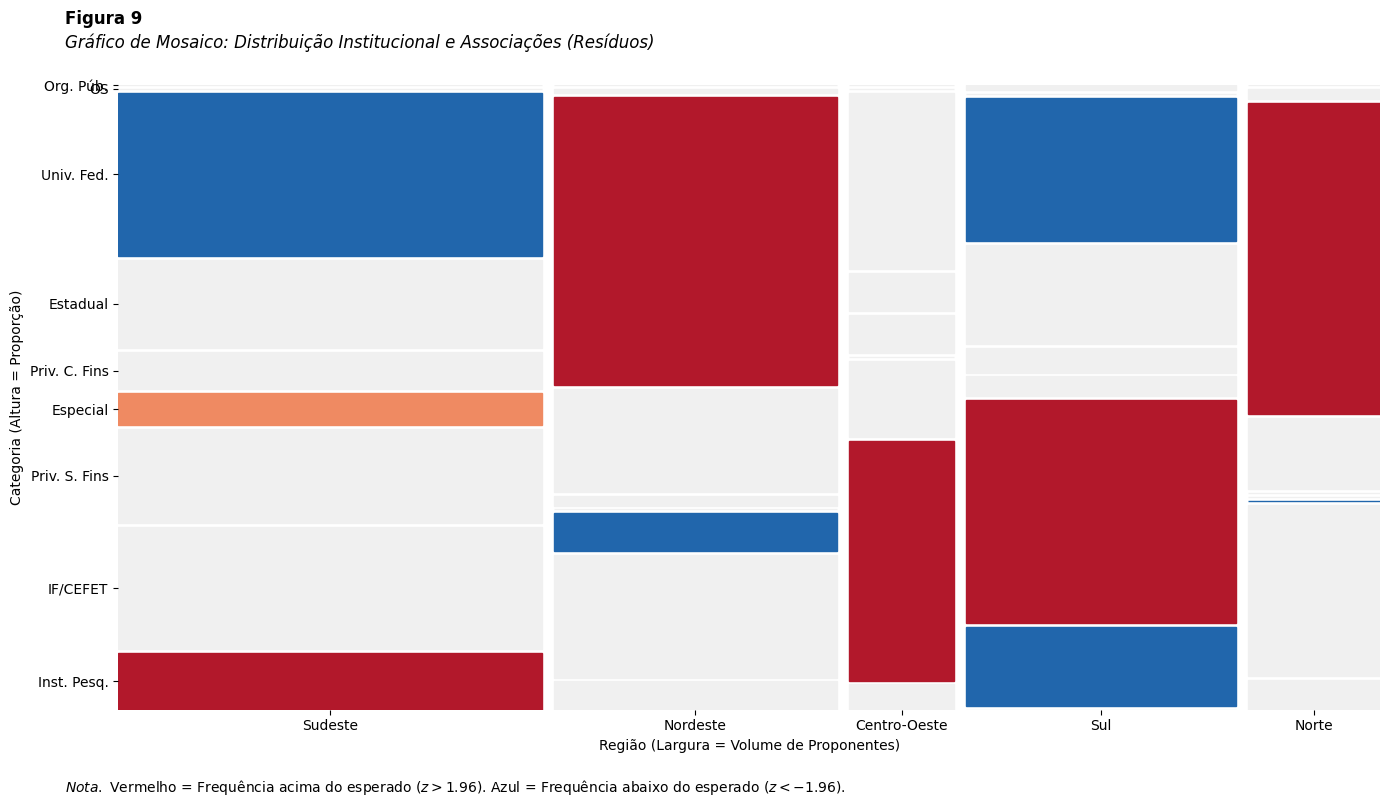

Gráfico PT gerado com sucesso.


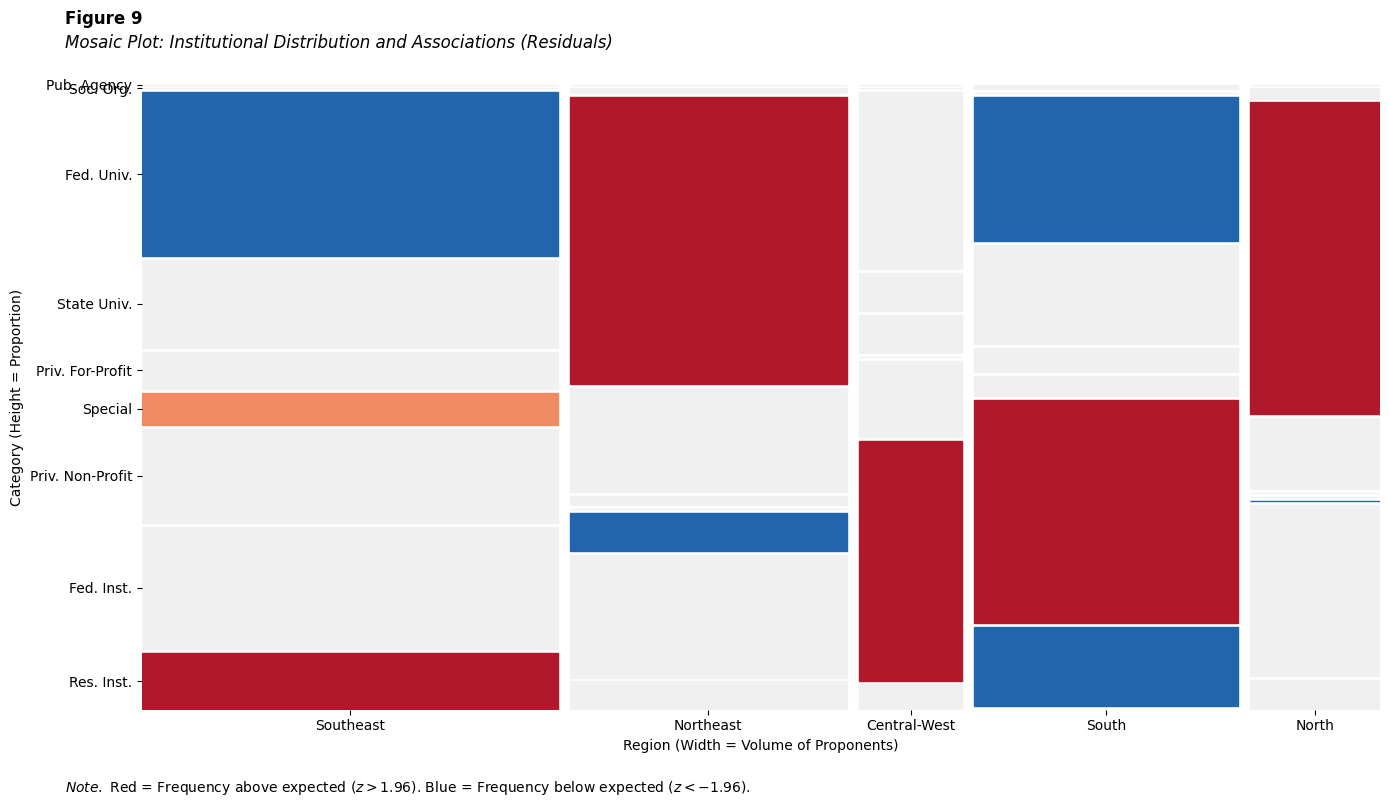

Gráfico EN gerado com sucesso.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.mosaicplot import mosaic
from matplotlib import rcParams

# ==============================================================================
# 1. CONFIGURAÇÃO ESTÉTICA (APA 7)
# ==============================================================================
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 10
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.left'] = False
rcParams['axes.spines.bottom'] = False

# ==============================================================================
# 2. PREPARAÇÃO DOS DADOS
# ==============================================================================
try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)
except Exception as e:
    print(f"Erro ao ler arquivo: {e}")
    # Cria um df vazio apenas para não quebrar a execução se o arquivo não existir
    df = pd.DataFrame()

# Mapeamento de Nomes Curtos (PT)
mapa_nomes_curtos_pt = {
    'Universidade Federal': 'Univ. Fed.',
    'IF/CEFET': 'IF/CEFET',
    'PRIVADA SEM FINS LUCRATIVOS': 'Priv. S. Fins',
    'PRIVADA COM FINS LUCRATIVOS': 'Priv. C. Fins',
    'INSTITUTO DE PESQUISA': 'Inst. Pesq.',
    'PUBLICA ESTADUAL': 'Estadual',
    'ORGANIZACAO SOCIAL': 'OS',
    'ORGAO PUBLICO': 'Org. Púb.',
    'ESPECIAL': 'Especial'
}

# Criar coluna de nomes curtos e tratar possíveis falhas (fillna)
df['cat_curta_pt'] = df['categoria_adm_corrigida'].map(mapa_nomes_curtos_pt).fillna('Outros')

# Mapeamento de Nomes Curtos (EN)
mapa_regioes_en = {
    'Centro-Oeste': 'Central-West', 'Nordeste': 'Northeast',
    'Norte': 'North', 'Sudeste': 'Southeast', 'Sul': 'South'
}
mapa_cats_en = {
    'Univ. Fed.': 'Fed. Univ.',
    'IF/CEFET': 'Fed. Inst.',
    'Priv. S. Fins': 'Priv. Non-Profit',
    'Priv. C. Fins': 'Priv. For-Profit',
    'Inst. Pesq.': 'Res. Inst.',
    'Estadual': 'State Univ.',
    'OS': 'Soc. Org.',
    'Org. Púb.': 'Pub. Agency',
    'Especial': 'Special',
    'Outros': 'Others'
}

df['regiao_en'] = df['regiao_corrigida'].map(mapa_regioes_en)
df['cat_curta_en'] = df['cat_curta_pt'].map(mapa_cats_en)

# ==============================================================================
# 3. DEFINIÇÃO EXPLÍCITA DAS CORES (RESÍDUOS)
# ==============================================================================
# Definimos as cores diretas para as chaves (Região, Categoria Curta)
# Isso evita erros de cálculo dinâmico.

# Cores: Vermelho Forte (#b2182b), Vermelho Claro (#ef8a62), Azul Forte (#2166ac), Azul Claro (#67a9cf)
colors_pt = {
    ('Sul', 'Priv. S. Fins'): '#b2182b',      # Excesso Crítico (+7.05)
    ('Nordeste', 'Univ. Fed.'): '#b2182b',    # Excesso Forte (+3.73)
    ('Norte', 'Univ. Fed.'): '#b2182b',       # Excesso Forte (+3.08)
    ('Centro-Oeste', 'IF/CEFET'): '#b2182b',  # Excesso Forte (+3.28)
    ('Sudeste', 'Inst. Pesq.'): '#b2182b',    # Excesso Forte (+3.15)
    ('Sudeste', 'Especial'): '#ef8a62',       # Excesso Moderado (+2.90)

    ('Sul', 'IF/CEFET'): '#2166ac',           # Falta Crítica (-2.50)
    ('Sul', 'Univ. Fed.'): '#2166ac',         # Falta Crítica (-2.72)
    ('Sudeste', 'Univ. Fed.'): '#2166ac',     # Falta Crítica (-2.53)
    ('Nordeste', 'Priv. S. Fins'): '#2166ac', # Falta Crítica (-3.49)
    ('Norte', 'Priv. S. Fins'): '#2166ac'     # Falta Crítica (-3.61)
}

# Versão em Inglês das mesmas chaves de cor
colors_en = {
    ('South', 'Priv. Non-Profit'): '#b2182b',
    ('Northeast', 'Fed. Univ.'): '#b2182b',
    ('North', 'Fed. Univ.'): '#b2182b',
    ('Central-West', 'Fed. Inst.'): '#b2182b',
    ('Southeast', 'Res. Inst.'): '#b2182b',
    ('Southeast', 'Special'): '#ef8a62',

    ('South', 'Fed. Inst.'): '#2166ac',
    ('South', 'Fed. Univ.'): '#2166ac',
    ('Southeast', 'Fed. Univ.'): '#2166ac',
    ('Northeast', 'Priv. Non-Profit'): '#2166ac',
    ('North', 'Priv. Non-Profit'): '#2166ac'
}

def get_color_pt(key):
    # key vem como (Região, Categoria)
    return {'color': colors_pt.get(key, '#f0f0f0')} # Cinza padrão se não tiver resíduo forte

def get_color_en(key):
    return {'color': colors_en.get(key, '#f0f0f0')}

# ==============================================================================
# 4. PLOTAGEM SEGURA
# ==============================================================================

# --- VERSÃO PORTUGUÊS ---
fig, ax = plt.subplots(figsize=(14, 8))
try:
    mosaic(df, index=['regiao_corrigida', 'cat_curta_pt'], ax=ax,
           properties=get_color_pt, gap=0.01, labelizer=lambda k: "")

    # Textos APA
    fig.text(0.05, 0.98, "Figura 9", fontsize=12, weight='bold')
    fig.text(0.05, 0.95, "Gráfico de Mosaico: Distribuição Institucional e Associações (Resíduos)", fontsize=12, style='italic')
    fig.text(0.05, 0.02, r"$\it{Nota.}$ Vermelho = Frequência acima do esperado ($z > 1.96$). Azul = Frequência abaixo do esperado ($z < -1.96$).", fontsize=10)

    ax.set_xlabel('Região (Largura = Volume de Proponentes)', fontsize=10)
    ax.set_ylabel('Categoria (Altura = Proporção)', fontsize=10)

    plt.tight_layout(rect=[0, 0.05, 1, 0.93])
    plt.savefig('apa_fig9_mosaic_PT_safe.png', dpi=300)
    plt.show()
    print("Gráfico PT gerado com sucesso.")
except Exception as e:
    print(f"Erro ao gerar gráfico PT: {e}")

# --- VERSÃO INGLÊS ---
fig, ax = plt.subplots(figsize=(14, 8))
try:
    mosaic(df, index=['regiao_en', 'cat_curta_en'], ax=ax,
           properties=get_color_en, gap=0.01, labelizer=lambda k: "")

    # Textos APA
    fig.text(0.05, 0.98, "Figure 9", fontsize=12, weight='bold')
    fig.text(0.05, 0.95, "Mosaic Plot: Institutional Distribution and Associations (Residuals)", fontsize=12, style='italic')
    fig.text(0.05, 0.02, r"$\it{Note.}$ Red = Frequency above expected ($z > 1.96$). Blue = Frequency below expected ($z < -1.96$).", fontsize=10)

    ax.set_xlabel('Region (Width = Volume of Proponents)', fontsize=10)
    ax.set_ylabel('Category (Height = Proportion)', fontsize=10)

    plt.tight_layout(rect=[0, 0.05, 1, 0.93])
    plt.savefig('apa_fig9_mosaic_EN_safe.png', dpi=300)
    plt.show()
    print("Gráfico EN gerado com sucesso.")
except Exception as e:
    print(f"Erro ao gerar gráfico EN: {e}")

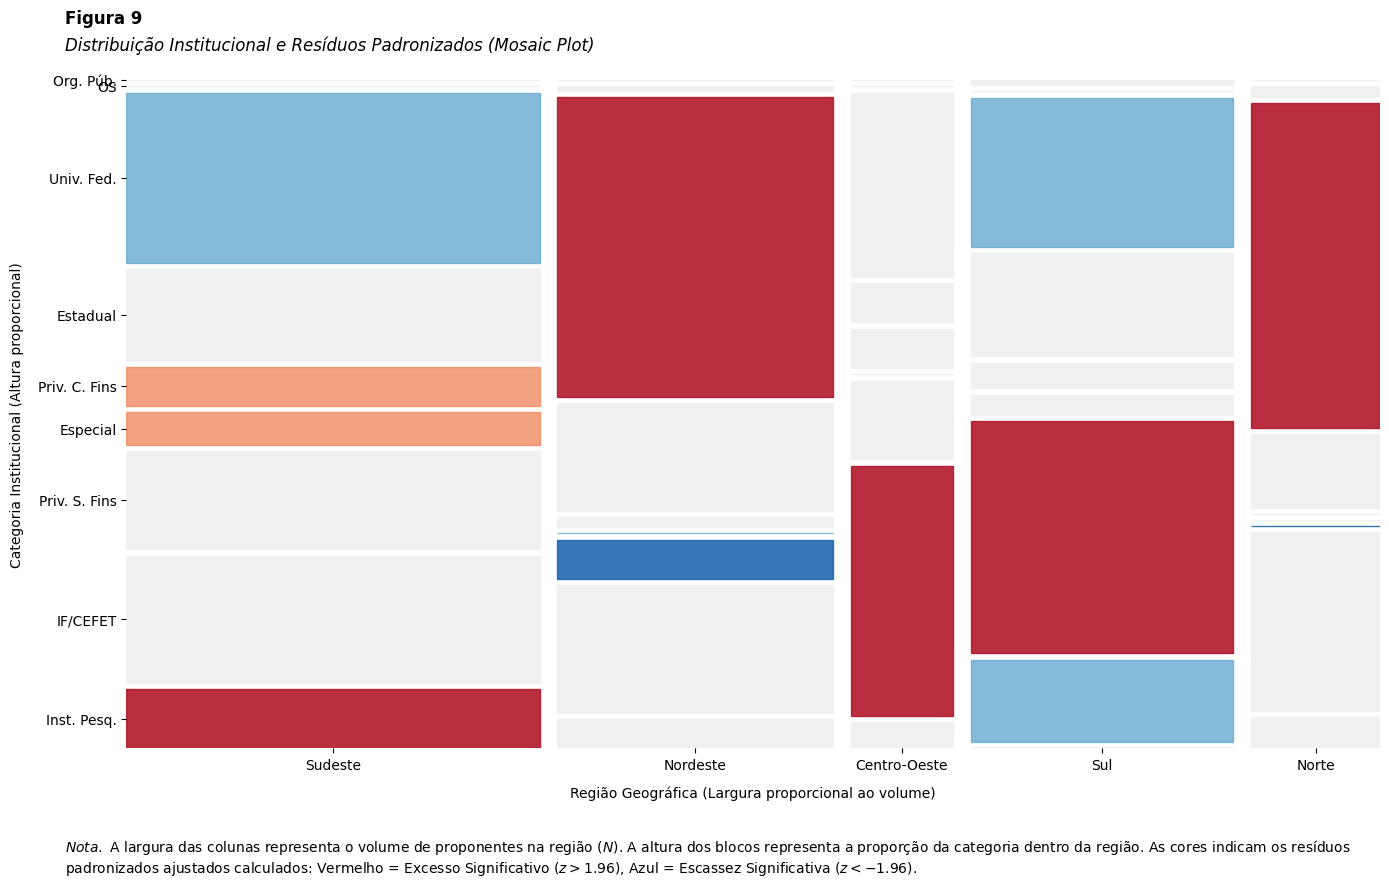

Gráfico gerado com sucesso!


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.mosaicplot import mosaic
from scipy.stats import chi2_contingency
from matplotlib import rcParams

# ==============================================================================
# 1. CONFIGURAÇÃO ESTÉTICA (PADRÃO APA 7)
# ==============================================================================
# Limpa parâmetros anteriores para garantir o estilo
plt.rcParams.update(plt.rcParamsDefault)

# Fontes e Tamanhos
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 10
rcParams['axes.titlesize'] = 12
rcParams['figure.titlesize'] = 12

# Remover bordas desnecessárias (Chartjunk)
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.left'] = False
rcParams['axes.spines.bottom'] = False

# ==============================================================================
# 2. CARREGAMENTO E PREPARAÇÃO DOS DADOS
# ==============================================================================
try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)
except Exception as e:
    print(f"Erro ao ler o arquivo: {e}")
    # Cria df vazio para evitar erro de execução se o arquivo não estiver lá
    df = pd.DataFrame(columns=['categoria_adm_corrigida', 'regiao_corrigida'])

# Mapeamento para nomes curtos (Melhora a leitura no gráfico)
mapa_nomes_pt = {
    'Universidade Federal': 'Univ. Fed.',
    'IF/CEFET': 'IF/CEFET',
    'PRIVADA SEM FINS LUCRATIVOS': 'Priv. S. Fins',
    'PRIVADA COM FINS LUCRATIVOS': 'Priv. C. Fins',
    'INSTITUTO DE PESQUISA': 'Inst. Pesq.',
    'PUBLICA ESTADUAL': 'Estadual',
    'ORGANIZACAO SOCIAL': 'OS',
    'ORGAO PUBLICO': 'Org. Púb.',
    'ESPECIAL': 'Especial'
}

# Aplicar o mapeamento
df['cat_curta'] = df['categoria_adm_corrigida'].map(mapa_nomes_pt).fillna('Outros')

# ==============================================================================
# 3. CÁLCULO ESTATÍSTICO DOS RESÍDUOS (A "MÁGICA" DO JAMOVI)
# ==============================================================================
def calcular_residuos_ajustados(df_dados):
    # Cria a tabela de contingência
    tabela = pd.crosstab(df_dados['regiao_corrigida'], df_dados['cat_curta'])
    observado = tabela.values

    # Calcula Qui-Quadrado e Esperado
    chi2, p, dof, esperado = chi2_contingency(observado)

    # Totais para o cálculo do resíduo ajustado
    n_total = observado.sum()
    total_linhas = observado.sum(axis=1)
    total_colunas = observado.sum(axis=0)

    prop_linhas = total_linhas / n_total
    prop_colunas = total_colunas / n_total

    # Cálculo vetorizado do Resíduo Padronizado Ajustado (Adjusted Standardized Residual)
    # Fórmula: (O - E) / sqrt(E * (1 - p_linha) * (1 - p_coluna))
    divisor = np.sqrt(esperado * (1 - prop_linhas[:, np.newaxis]) * (1 - prop_colunas[np.newaxis, :]))

    # Tratamento para evitar divisão por zero
    with np.errstate(divide='ignore', invalid='ignore'):
        residuos = (observado - esperado) / divisor

    return pd.DataFrame(residuos, index=tabela.index, columns=tabela.columns).fillna(0)

# Executa o cálculo
df_residuos = calcular_residuos_ajustados(df)

# ==============================================================================
# 4. FUNÇÃO DE CORES (PINTAR CONFORME O DADO)
# ==============================================================================
def obter_cor(key):
    # key é uma tupla que o mosaic envia: (Região, Categoria)
    try:
        regiao, categoria = key
        residuo = df_residuos.loc[regiao, categoria]
    except KeyError:
        residuo = 0

    # Paleta baseada na magnitude do resíduo (z-score)
    if residuo > 3: return {'color': '#b2182b', 'alpha': 0.9}      # Vermelho Escuro (Excesso Crítico)
    if residuo > 1.96: return {'color': '#ef8a62', 'alpha': 0.8}   # Vermelho Claro (Significativo)
    if residuo < -3: return {'color': '#2166ac', 'alpha': 0.9}     # Azul Escuro (Falta Crítica)
    if residuo < -1.96: return {'color': '#67a9cf', 'alpha': 0.8}  # Azul Claro (Significativo)

    return {'color': '#f0f0f0', 'alpha': 1.0}                      # Cinza/Branco (Neutro)

# ==============================================================================
# 5. GERAR O GRÁFICO (PLOT)
# ==============================================================================
fig, ax = plt.subplots(figsize=(14, 9))

# Desenha o Mosaico
# index=['regiao_corrigida', 'cat_curta'] define a ordem: Colunas=Região, Blocos=Categoria
mosaic(df, index=['regiao_corrigida', 'cat_curta'], ax=ax,
       properties=obter_cor, gap=0.015, labelizer=lambda k: "") # gap cria o espaço branco entre blocos

# Ajustes de Eixos e Títulos (Estilo APA)
# Título e Número da Figura
fig.text(0.05, 0.96, "Figura 9", fontsize=12, weight='bold')
fig.text(0.05, 0.93, "Distribuição Institucional e Resíduos Padronizados (Mosaic Plot)", fontsize=12, style='italic')

# Legenda/Nota Explicativa (Essencial para APA)
nota_texto = (
    r"$\it{Nota.}$ A largura das colunas representa o volume de proponentes na região ($N$). "
    "A altura dos blocos representa a proporção da categoria dentro da região. "
    "As cores indicam os resíduos padronizados ajustados calculados: "
    "Vermelho = Excesso Significativo ($z > 1.96$), Azul = Escassez Significativa ($z < -1.96$)."
)
fig.text(0.05, 0.02, nota_texto, fontsize=10, ha='left', wrap=True)

# Rótulos dos Eixos
ax.set_xlabel('Região Geográfica (Largura proporcional ao volume)', fontsize=10, labelpad=10)
ax.set_ylabel('Categoria Institucional (Altura proporcional)', fontsize=10, labelpad=10)

plt.tight_layout(rect=[0, 0.08, 1, 0.92]) # Ajusta margens para caber texto
plt.savefig('apa_fig9_mosaic_final.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico gerado com sucesso!")

Gerando Spineplot em Português...


/usr/local/lib/python3.12/dist-packages/statsmodels/graphics/mosaicplot.py:651: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rect = Rectangle((x, y), w, h, label=text, **props)


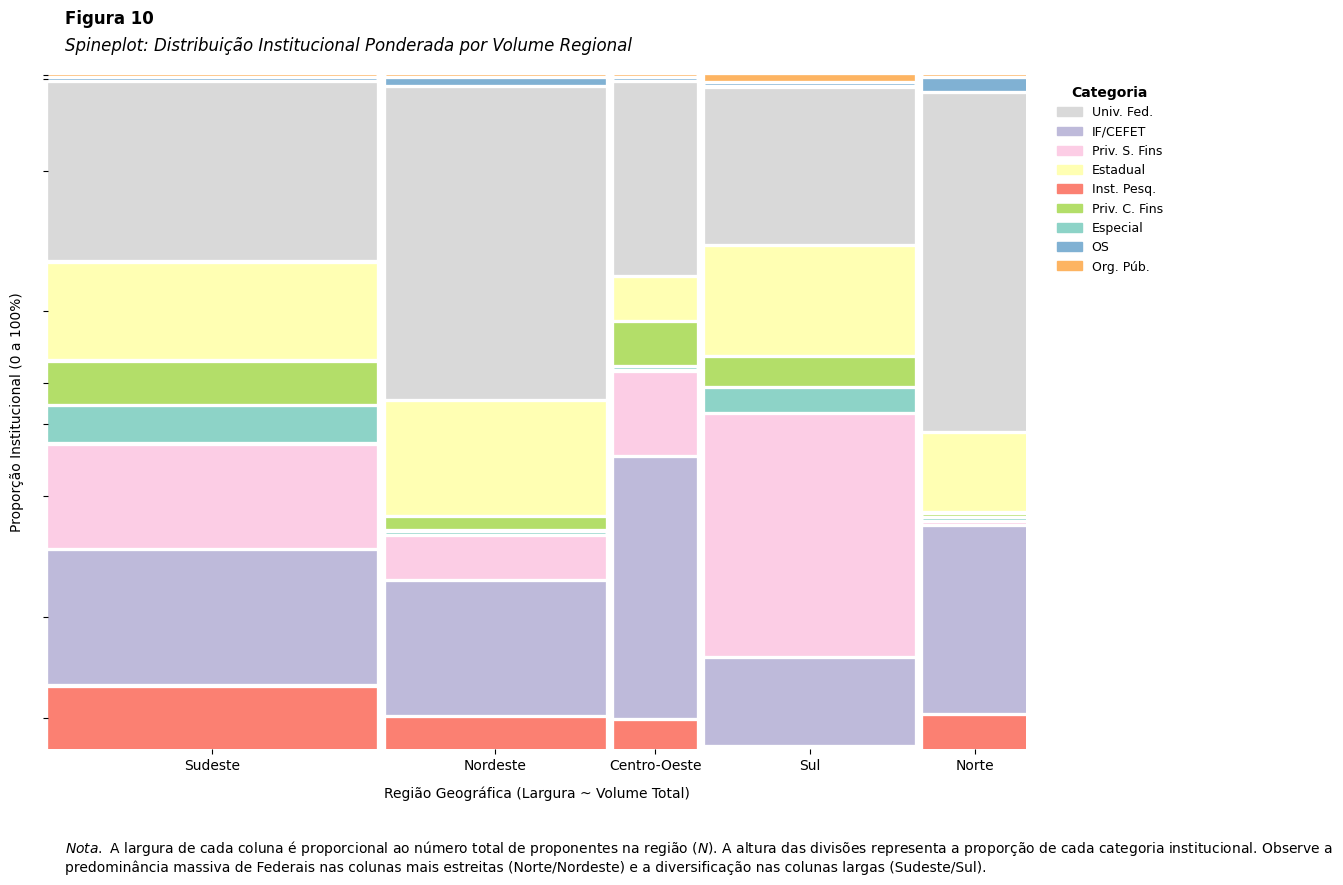


Gerando Spineplot em Inglês...


/usr/local/lib/python3.12/dist-packages/statsmodels/graphics/mosaicplot.py:651: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rect = Rectangle((x, y), w, h, label=text, **props)


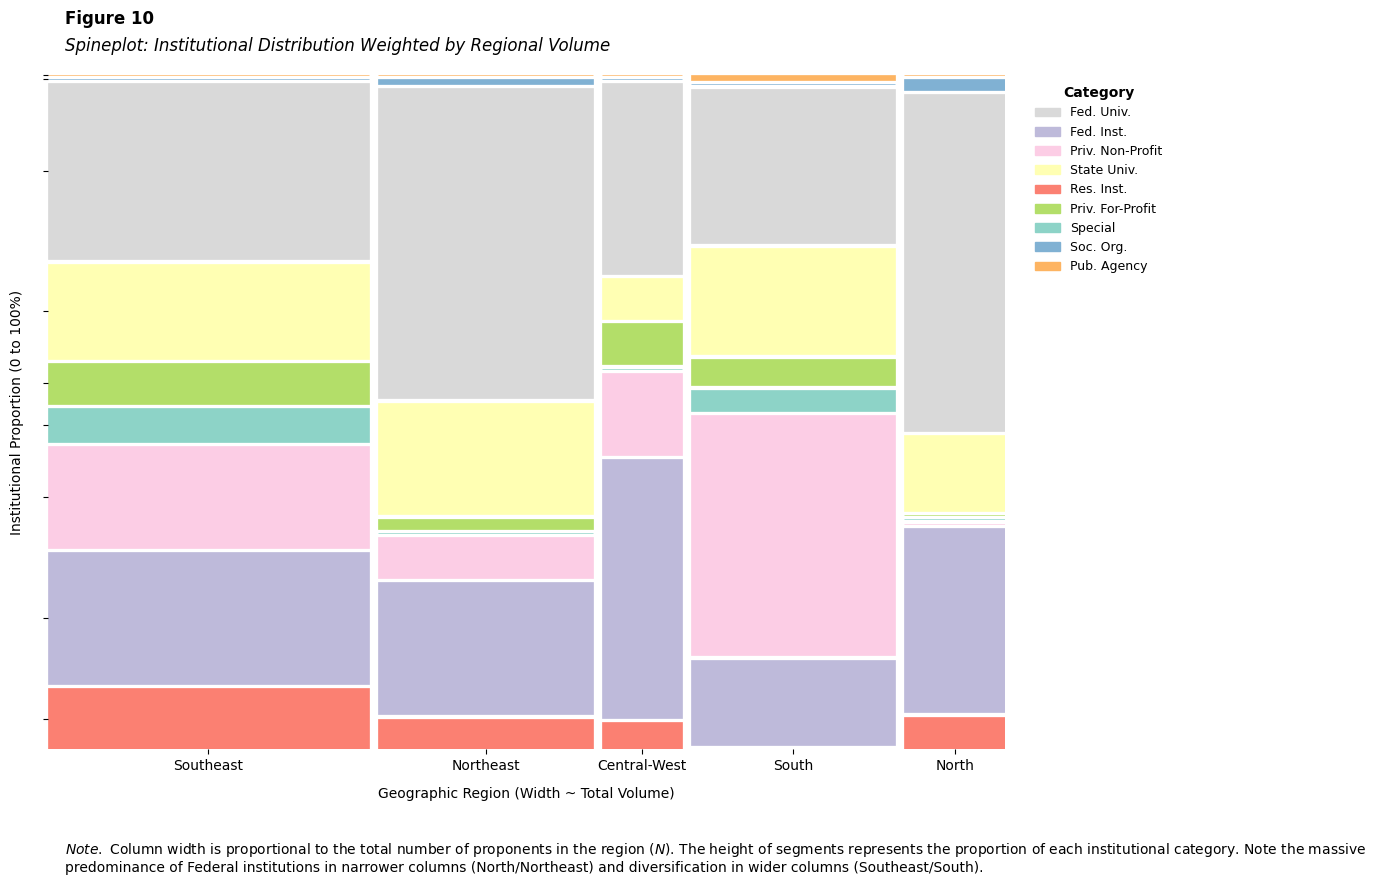

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from statsmodels.graphics.mosaicplot import mosaic
from matplotlib import rcParams

# ==============================================================================
# 1. CONFIGURAÇÃO ESTÉTICA (APA 7)
# ==============================================================================
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 10
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.left'] = False
rcParams['axes.spines.bottom'] = False

# ==============================================================================
# 2. DADOS E PREPARAÇÃO
# ==============================================================================
try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)
except Exception as e:
    print(f"Erro ao ler arquivo: {e}")
    df = pd.DataFrame(columns=['categoria_adm_corrigida', 'regiao_corrigida'])

# Mapeamentos (Nomes Curtos)
mapa_nomes_pt = {
    'Universidade Federal': 'Univ. Fed.',
    'IF/CEFET': 'IF/CEFET',
    'PRIVADA SEM FINS LUCRATIVOS': 'Priv. S. Fins',
    'PRIVADA COM FINS LUCRATIVOS': 'Priv. C. Fins',
    'INSTITUTO DE PESQUISA': 'Inst. Pesq.',
    'PUBLICA ESTADUAL': 'Estadual',
    'ORGANIZACAO SOCIAL': 'OS',
    'ORGAO PUBLICO': 'Org. Púb.',
    'ESPECIAL': 'Especial'
}

mapa_regioes_en = {'Centro-Oeste': 'Central-West', 'Nordeste': 'Northeast',
                   'Norte': 'North', 'Sudeste': 'Southeast', 'Sul': 'South'}

mapa_cats_en = {
    'Univ. Fed.': 'Fed. Univ.', 'IF/CEFET': 'Fed. Inst.', 'Priv. S. Fins': 'Priv. Non-Profit',
    'Priv. C. Fins': 'Priv. For-Profit', 'Inst. Pesq.': 'Res. Inst.', 'Estadual': 'State Univ.',
    'OS': 'Soc. Org.', 'Org. Púb.': 'Pub. Agency', 'Especial': 'Special'
}

df['cat_pt'] = df['categoria_adm_corrigida'].map(mapa_nomes_pt).fillna('Outros')
df['reg_pt'] = df['regiao_corrigida']
df['cat_en'] = df['cat_pt'].map(mapa_cats_en).fillna('Others')
df['reg_en'] = df['regiao_corrigida'].map(mapa_regioes_en)

# ==============================================================================
# 3. DEFINIÇÃO DE CORES CATEGÓRICAS (CONSISTÊNCIA VISUAL)
# ==============================================================================
# Usaremos uma paleta qualitativa (Set3 ou tab10) para distinguir as instituições
# Mapeando cores fixas para garantir que "Federal" seja a mesma cor em ambos os gráficos
# Cores Hex para consistência
palette = [
    '#8dd3c7', '#ffffb3', '#bebada', '#fb8072', '#80b1d3',
    '#fdb462', '#b3de69', '#fccde5', '#d9d9d9', '#bc80bd'
]

# Criar dicionário de cores para PT
categorias_unicas_pt = sorted(list(mapa_nomes_pt.values()))
color_map_pt = {cat: palette[i % len(palette)] for i, cat in enumerate(categorias_unicas_pt)}

# Criar dicionário de cores para EN (baseado na tradução para manter a mesma cor)
color_map_en = {mapa_cats_en[k]: v for k, v in color_map_pt.items() if k in mapa_cats_en}

# ==============================================================================
# 4. FUNÇÃO DE PLOTAGEM DO SPINEPLOT
# ==============================================================================
def plot_spineplot(lang='pt'):
    # Seleção de Colunas e Mapas
    col_reg = 'reg_pt' if lang == 'pt' else 'reg_en'
    col_cat = 'cat_pt' if lang == 'pt' else 'cat_en'
    color_map = color_map_pt if lang == 'pt' else color_map_en

    # Função de propriedades para o mosaic pintar por categoria
    def props(key):
        # key = (Região, Categoria)
        cat = key[1]
        return {'color': color_map.get(cat, '#eaeaea'), 'edgecolor': 'white', 'linewidth': 0.5}

    fig, ax = plt.subplots(figsize=(14, 9))

    # Gerar Spineplot (via Mosaic)
    # A ordem index=[Região, Categoria] garante: Região no Eixo X (largura), Categoria no Eixo Y (empilhado)
    mosaic(df, index=[col_reg, col_cat], ax=ax, properties=props, gap=0.01, labelizer=lambda k: "")

    # Criar Legenda Manual (Clean APA Style)
    # Como o mosaic não gera legenda automática para cores categóricas customizadas, criamos patches
    patches = []
    # Ordenar legenda pela frequência geral para que as categorias maiores fiquem no topo da legenda
    ordem_cats = df[col_cat].value_counts().index
    for cat in ordem_cats:
        if cat in color_map:
            patches.append(mpatches.Patch(color=color_map[cat], label=cat))

    # Posicionar legenda fora do gráfico à direita
    legend = ax.legend(handles=patches, title="Categoria" if lang=='pt' else "Category",
              bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=9)
    legend.get_title().set_fontweight('bold')

    # Textos APA
    if lang == 'pt':
        fig.text(0.05, 0.96, "Figura 10", fontsize=12, weight='bold')
        fig.text(0.05, 0.93, "Spineplot: Distribuição Institucional Ponderada por Volume Regional", fontsize=12, style='italic')
        note = (r"$\it{Nota.}$ A largura de cada coluna é proporcional ao número total de proponentes na região ($N$). "
                "A altura das divisões representa a proporção de cada categoria institucional. "
                "Observe a predominância massiva de Federais nas colunas mais estreitas (Norte/Nordeste) e a diversificação nas colunas largas (Sudeste/Sul).")
        xlab = 'Região Geográfica (Largura ~ Volume Total)'
        ylab = 'Proporção Institucional (0 a 100%)'
        filename = 'apa_fig10_spineplot_PT.png'
    else:
        fig.text(0.05, 0.96, "Figure 10", fontsize=12, weight='bold')
        fig.text(0.05, 0.93, "Spineplot: Institutional Distribution Weighted by Regional Volume", fontsize=12, style='italic')
        note = (r"$\it{Note.}$ Column width is proportional to the total number of proponents in the region ($N$). "
                "The height of segments represents the proportion of each institutional category. "
                "Note the massive predominance of Federal institutions in narrower columns (North/Northeast) and diversification in wider columns (Southeast/South).")
        xlab = 'Geographic Region (Width ~ Total Volume)'
        ylab = 'Institutional Proportion (0 to 100%)'
        filename = 'apa_fig10_spineplot_EN.png'

    fig.text(0.05, 0.02, note, fontsize=10, ha='left', wrap=True)
    ax.set_xlabel(xlab, fontsize=10, labelpad=10)
    ax.set_ylabel(ylab, fontsize=10, labelpad=10)

    # Remover ticks do eixo Y (já que é proporção visual) ou limpar labels internos
    ax.set_yticklabels([])

    plt.tight_layout(rect=[0, 0.08, 0.85, 0.92]) # Margem direita maior para legenda
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# Executar
print("Gerando Spineplot em Português...")
plot_spineplot('pt')

print("\nGerando Spineplot em Inglês...")
plot_spineplot('en')

Gerando Ridgeline com Espaçamento Corrigido (PT)...


/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_a

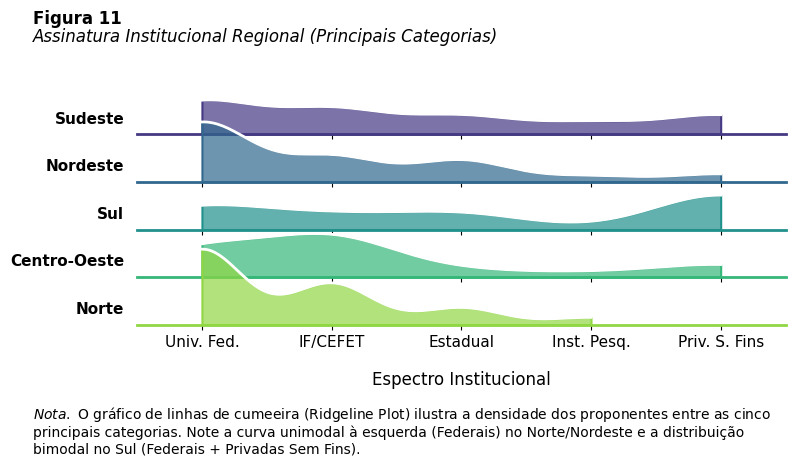


Gerando Ridgeline com Espaçamento Corrigido (EN)...


/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_a

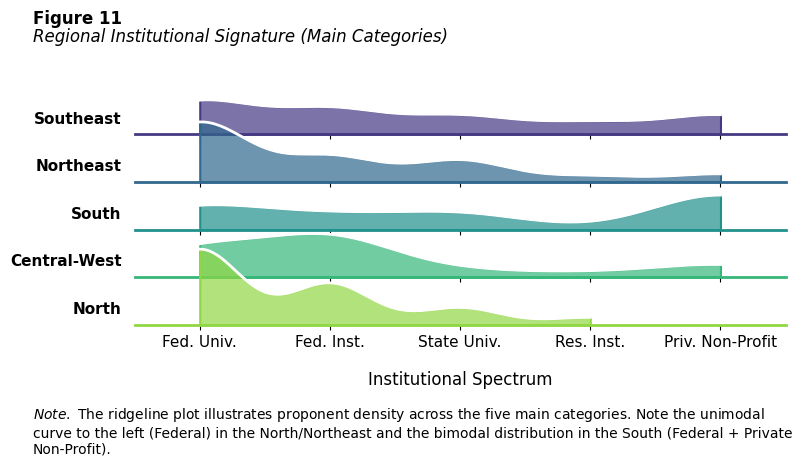

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib import rcParams

# ==============================================================================
# 1. CONFIGURAÇÃO ESTÉTICA (APA 7)
# ==============================================================================
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 11
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.left'] = True
rcParams['axes.spines.bottom'] = True
rcParams['axes.facecolor'] = (0, 0, 0, 0)

# ==============================================================================
# 2. DADOS E PREPARAÇÃO
# ==============================================================================
try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df_raw = pd.read_csv(nome_arquivo)
except:
    df_raw = pd.DataFrame()

# As 5 Categorias Principais (Filtro de Clareza)
cats_principais = [
    'Universidade Federal',
    'IF/CEFET',
    'PUBLICA ESTADUAL',
    'INSTITUTO DE PESQUISA',
    'PRIVADA SEM FINS LUCRATIVOS'
]

df = df_raw[df_raw['categoria_adm_corrigida'].isin(cats_principais)].copy()
cat_map_pt = {cat: i for i, cat in enumerate(cats_principais)}
df['cat_code'] = df['categoria_adm_corrigida'].map(cat_map_pt)

# Nomes para o Eixo X
labels_x_pt = ['Univ. Fed.', 'IF/CEFET', 'Estadual', 'Inst. Pesq.', 'Priv. S. Fins']
labels_x_en = ['Fed. Univ.', 'Fed. Inst.', 'State Univ.', 'Res. Inst.', 'Priv. Non-Profit']

# ==============================================================================
# 3. PLOTAGEM COM ESPAÇAMENTO CORRIGIDO
# ==============================================================================
def plot_ridgeline_spaced(lang='pt'):
    # Textos
    if lang == 'pt':
        title = "Assinatura Institucional Regional (Principais Categorias)"
        xlabel = "Espectro Institucional"
        fig_num = "Figura 11"
        note = (r"$\it{Nota.}$ O gráfico de linhas de cumeeira (Ridgeline Plot) ilustra a densidade dos proponentes "
                "entre as cinco principais categorias. Note a curva unimodal à esquerda (Federais) no Norte/Nordeste "
                "e a distribuição bimodal no Sul (Federais + Privadas Sem Fins).")
        labels_x = labels_x_pt
        filename = "apa_fig11_ridgeline_spaced_PT.png"
    else:
        title = "Regional Institutional Signature (Main Categories)"
        xlabel = "Institutional Spectrum"
        fig_num = "Figure 11"
        note = (r"$\it{Note.}$ The ridgeline plot illustrates proponent density across the five main categories. "
                "Note the unimodal curve to the left (Federal) in the North/Northeast and the bimodal distribution "
                "in the South (Federal + Private Non-Profit).")
        labels_x = labels_x_en
        filename = "apa_fig11_ridgeline_spaced_EN.png"

    # Criar Grid
    g = sns.FacetGrid(df, row="regiao_corrigida", hue="regiao_corrigida", aspect=9, height=0.9, palette="viridis")

    # Desenhar Curvas
    g.map(sns.kdeplot, "cat_code", clip_on=False, shade=True, alpha=0.7, lw=1.5, bw_adjust=0.8, cut=0)
    g.map(sns.kdeplot, "cat_code", clip_on=False, color="white", lw=2, bw_adjust=0.8, cut=0)
    g.map(plt.axhline, y=0, lw=2, clip_on=False)

    # Rótulos Laterais (Regiões)
    def label(x, color, label):
        ax = plt.gca()
        if lang == 'en':
            map_reg = {'Centro-Oeste': 'Central-West', 'Nordeste': 'Northeast', 'Norte': 'North', 'Sudeste': 'Southeast', 'Sul': 'South'}
            label = map_reg.get(label, label)
        ax.text(-0.02, 0.2, label, fontweight="bold", color='black', ha="right", va="center", transform=ax.transAxes)

    g.map(label, "cat_code")

    # Ajustes de Layout
    g.fig.subplots_adjust(hspace=-0.4) # Sobreposição das montanhas
    g.set_titles("")
    g.set(yticks=[], ylabel="")
    g.despine(bottom=True, left=True)

    # --- CORREÇÃO DO ESPAÇAMENTO ---

    # 1. Configurar Eixo X com padding extra
    plt.xticks(ticks=range(len(labels_x)), labels=labels_x, rotation=0, ha='center', fontsize=11)
    plt.xlim(-0.5, 4.5)
    plt.xlabel(xlabel, fontsize=12, labelpad=15) # labelpad=15 empurra o título "Espectro..." para baixo

    # 2. Ajustar margem inferior da figura inteira
    # Isso cria um "rodapé" vazio de 20% da altura total da imagem
    g.fig.subplots_adjust(bottom=0.30, top=0.90)

    # 3. Posicionar Cabeçalho e Nota
    # Títulos no topo
    g.fig.text(0.05, 0.97, fig_num, fontsize=12, weight='bold')
    g.fig.text(0.05, 0.93, title, fontsize=12, style='italic')

    # Nota no Rodapé (Agora com espaço garantido)
    # y=0.02 coloca o texto bem na base da área reservada pelo subplots_adjust
    g.fig.text(0.05, 0.02, note, fontsize=10, ha='left', wrap=True)

    # Salvar
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# Executar
print("Gerando Ridgeline com Espaçamento Corrigido (PT)...")
plot_ridgeline_spaced('pt')

print("\nGerando Ridgeline com Espaçamento Corrigido (EN)...")
plot_ridgeline_spaced('en')